In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils import class_weight

2025-10-14 10:28:47.105209: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-14 10:28:47.212736: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-14 10:28:49.524492: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("✅ GPU available and memory growth enabled")
    except RuntimeError as e:
        print(e)
else:
    print("⚠️ No GPU found, training will run on CPU")


✅ GPU available and memory growth enabled


In [3]:
print("TensorFlow version:", tf.__version__)
print("Built with CUDA:", tf.test.is_built_with_cuda())
print("Physical GPUs:", tf.config.list_physical_devices("GPU"))
print("GPU device name:", tf.test.gpu_device_name())


TensorFlow version: 2.20.0
Built with CUDA: True
Physical GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU device name: /device:GPU:0


I0000 00:00:1760417931.723462   16426 gpu_device.cc:2020] Created device /device:GPU:0 with 5368 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [4]:
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy("mixed_float16")


In [5]:
# =========================
import os

DATA_DIR = os.path.expanduser("/home/lakshya/jupyter/paper/DFU/Patches/data/")   # change to your dataset path
IMG_SIZE = 224
BATCH = 32
EPOCHS = 30

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATA_DIR, image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH, validation_split=0.2,
    subset="training", seed=1337, label_mode="int"
)
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATA_DIR, image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH, validation_split=0.2,
    subset="validation", seed=1337, label_mode="int"
)
class_names = train_ds.class_names
print("Classes:", class_names)

Found 1837 files belonging to 4 classes.
Using 1470 files for training.


I0000 00:00:1760417931.789222   16426 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5368 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Found 1837 files belonging to 4 classes.
Using 367 files for validation.
Classes: ['Abnormal(Ulcer)', 'Normal(Healthy skin)', 'Wound Images', 'Wound Images2']


In [6]:
labels = np.concatenate([y.numpy() for _, y in train_ds], axis=0)
cw_vals = class_weight.compute_class_weight("balanced", classes=np.unique(labels), y=labels)
class_weights = {int(c): float(w) for c, w in zip(np.unique(labels), cw_vals)}
print("Class weights:", class_weights)

Class weights: {0: 0.9074074074074074, 1: 0.8467741935483871, 2: 4.083333333333333, 3: 0.6792975970425139}


2025-10-14 10:28:53.208002: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [7]:
inputs = layers.Input((IMG_SIZE, IMG_SIZE, 3))
x = layers.Rescaling(1./127.5, offset=-1)(inputs)

base = tf.keras.applications.MobileNetV2(include_top=False,
                                         input_shape=(IMG_SIZE,IMG_SIZE,3),
                                         weights="imagenet")
base.trainable = False   # freeze base for initial training

x = base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(len(class_names), activation="softmax", dtype="float32")(x)  

In [8]:
model = models.Model(inputs, outputs)
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,586,948 (9.87 MB)

 Trainable params: 328,964 (1.25 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [9]:
ckpt = callbacks.ModelCheckpoint("best_mobilenetv2_gpu.h5", save_best_only=True,
                                 monitor="val_accuracy", mode="max")
es = callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True)


In [10]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[ckpt, es],
    class_weight=class_weights
)


Epoch 1/30


2025-10-14 10:28:56.679534: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f1c0c005030 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-10-14 10:28:56.679555: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
2025-10-14 10:28:57.078658: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-10-14 10:28:57.606485: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91400
2025-10-14 10:28:57.772471: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:17604179

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step - accuracy: 0.6442 - loss: 1.1400

46/46 ━━━━━━━━━━━━━━━━━━━━ 37s 529ms/step - accuracy: 0.7000 - loss: 0.9302 - val_accuracy: 0.6866 - val_loss: 0.6272
Epoch 2/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8041 - loss: 0.4621

46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8020 - loss: 0.4758 - val_accuracy: 0.8256 - val_loss: 0.3601
Epoch 3/30
43/46 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8739 - loss: 0.3645

46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.8354 - loss: 0.4116 - val_accuracy: 0.8638 - val_loss: 0.3345
Epoch 4/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.8755 - loss: 0.3606 - val_accuracy: 0.8311 - val_loss: 0.4108
Epoch 5/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8878 - loss: 0.2925 - val_accuracy: 0.8529 - val_loss: 0.3098
Epoch 6/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8966 - loss: 0.2658 - val_accuracy: 0.8283 - val_loss: 0.3740
Epoch 7/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9041 - loss: 0.2349 - val_accuracy: 0.8610 - val_loss: 0.3305
Epoch 8/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9223 - loss: 0.2052

46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9102 - loss: 0.2103 - val_accuracy: 0.8883 - val_loss: 0.2858
Epoch 9/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9340 - loss: 0.1910 - val_accuracy: 0.8529 - val_loss: 0.3416
Epoch 10/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9279 - loss: 0.1988 - val_accuracy: 0.8529 - val_loss: 0.3347
Epoch 11/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9293 - loss: 0.1759 - val_accuracy: 0.8747 - val_loss: 0.3231
Epoch 12/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9320 - loss: 0.1906 - val_accuracy: 0.8692 - val_loss: 0.3175
Epoch 13/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9367 - loss: 0.1785 - val_accuracy: 0.8828 - val_loss: 0.3359
Epoch 14/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9503 - loss: 0.1351 - val_accuracy: 0.8610 - val_loss: 0.3852


In [11]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[ckpt, es],
    class_weight=class_weights
)


Epoch 1/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9340 - loss: 0.1968 - val_accuracy: 0.8610 - val_loss: 0.3288
Epoch 2/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9245 - loss: 0.2129 - val_accuracy: 0.8719 - val_loss: 0.3260
Epoch 3/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9367 - loss: 0.1691 - val_accuracy: 0.8556 - val_loss: 0.3452
Epoch 4/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9048 - loss: 0.2452 - val_accuracy: 0.8638 - val_loss: 0.3637
Epoch 5/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9245 - loss: 0.2414 - val_accuracy: 0.8501 - val_loss: 0.3581
Epoch 6/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9435 - loss: 0.1588 - val_accuracy: 0.8747 - val_loss: 0.3457


In [12]:
loss, acc = model.evaluate(val_ds)
print(f"✅ Validation Loss: {loss:.16f}")
print(f"✅ Validation Accuracy: {acc:.16f}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8610 - loss: 0.3288
✅ Validation Loss: 0.3287610709667206
✅ Validation Accuracy: 0.8610354065895081


In [13]:
import os

# Search for .h5 or SavedModel folders recursively under your project
for root, dirs, files in os.walk(".", topdown=True):
    for f in files:
        if f.endswith(".h5"):
            print("Found model file:", os.path.join(root, f))
    if "saved_model.pb" in files:
        print("Found TensorFlow SavedModel:", root)


Found model file: ./best_mobilenetv2_gpu.h5
Found model file: ./dfu/lib/python3.13/site-packages/h5py/tests/data_files/vlen_string_dset_utc.h5
Found model file: ./dfu/lib/python3.13/site-packages/h5py/tests/data_files/vlen_string_s390x.h5
Found model file: ./dfu/lib/python3.13/site-packages/h5py/tests/data_files/vlen_string_dset.h5


In [14]:
import os
import sys
import csv
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt


In [15]:
TEST_DIR = "/home/lakshya/jupyter/paper/DFU/TestSet"        # change to your test folder if different
MODEL_PATH = "./best_mobilenetv2_gpu.h5"  # found model file
IMG_SIZE = 224
BATCH = 32
OUT_CSV = "test_predictions.csv"
CONF_MATRIX_PNG = "confusion_matrix.png"
LABELS_CSV_NAME = "labels.csv"   

In [16]:
IMG_EXTS = ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')

In [17]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for g in gpus:
            tf.config.experimental.set_memory_growth(g, True)
        print("✅ GPU(s) found - memory growth enabled")
    except Exception as e:
        print("⚠️ GPU setup issue:", e)
else:
    print("⚠️ No GPU found - running on CPU")


✅ GPU(s) found - memory growth enabled


In [18]:
def discover_images(root):
    paths = []
    for r, _, files in os.walk(root):
        for f in files:
            if f.lower().endswith(IMG_EXTS):
                paths.append(os.path.join(r, f))
    return sorted(paths)


In [19]:
def auto_infer_label_from_filename(fname):
    lower = fname.lower()
    KEYWORD_LABELS = {
        "infect": "infected",
        "ulcer": "infected",
        "pus": "infected",
        "abscess": "infected",
        "healthy": "healthy",
        "normal": "healthy",
        "noninfect": "healthy",
        "noinfect": "healthy"
    }
    for k, v in KEYWORD_LABELS.items():
        if k in lower:
            return v
    return "unknown"


In [20]:
def load_batch_images(paths, target_size):
    arr = np.zeros((len(paths), target_size, target_size, 3), dtype=np.float32)
    for i, p in enumerate(paths):
        img = image.load_img(p, target_size=(target_size, target_size))
        a = image.img_to_array(img).astype(np.float32)
        a = (a / 127.5) - 1.0  # MobileNetV2 expected preprocessing
        arr[i] = a
    return arr


In [21]:
if not os.path.isdir(TEST_DIR):
    print(f"ERROR: TEST_DIR does not exist: {TEST_DIR}")
    sys.exit(1)

all_images = discover_images(TEST_DIR)
print(f"Discovered {len(all_images)} image files under {TEST_DIR}")
if len(all_images) == 0:
    print("No image files found. Check TEST_DIR and extensions.")
    sys.exit(1)

Discovered 163 image files under /home/lakshya/jupyter/paper/DFU/TestSet


In [22]:
parents = [os.path.basename(os.path.dirname(p)) for p in all_images]
unique_parents = sorted(set(parents))

use_subfolders = False
if len(unique_parents) > 1:
    test_dir_base = os.path.basename(os.path.normpath(TEST_DIR))
    if any(p != test_dir_base for p in unique_parents):
        use_subfolders = True

filepaths = []
y_true = []
class_names = None


In [23]:
if use_subfolders:
    print("Detected class subfolders; inferring labels from immediate parent folder names.")
    class_names = sorted(list(set(parents)))
    class_to_idx = {c: i for i, c in enumerate(class_names)}
    for p in all_images:
        cls = os.path.basename(os.path.dirname(p))
        filepaths.append(p)
        y_true.append(class_to_idx[cls])
    print("Classes:", class_names)
else:
    print("Images appear to be in a single folder. Looking for labels CSV...")
    csv_candidates = [os.path.join(TEST_DIR, LABELS_CSV_NAME),
                      os.path.join(TEST_DIR, "test_labels.csv"),
                      os.path.join(TEST_DIR, "labels.csv")]
    csv_path = None
    for c in csv_candidates:
        if os.path.isfile(c):
            csv_path = c
            break

    if csv_path:
        print("Found labels CSV:", csv_path)
        df = pd.read_csv(csv_path)
        cols_lower = [c.lower() for c in df.columns]
        if 'filename' in cols_lower and 'label' in cols_lower:
            fname_col = df.columns[cols_lower.index('filename')]
            label_col = df.columns[cols_lower.index('label')]
        else:
            fname_col = df.columns[0]
            label_col = df.columns[1]
        mapping = {}
        for _, row in df.iterrows():
            base = os.path.basename(str(row[fname_col]))
            mapping[base] = str(row[label_col])
        matched = 0
        for p in all_images:
            b = os.path.basename(p)
            if b in mapping:
                filepaths.append(p)
                y_true.append(mapping[b])
                matched += 1
        if matched == 0:
            print("ERROR: labels CSV found but filenames did not match discovered images.")
            sys.exit(1)
        unique_labels = sorted(list(set(y_true)))
        class_names = unique_labels
        class_to_idx = {c: i for i, c in enumerate(class_names)}
        y_true = [class_to_idx[s] for s in y_true]
        print(f"Loaded {len(filepaths)} labeled images from CSV. Classes: {class_names}")
    else:
        print("No labels CSV found. Attempting to auto-infer labels from filenames (keywords).")
        rows = []
        for p in all_images:
            base = os.path.basename(p)
            inferred = auto_infer_label_from_filename(base)
            rows.append((base, inferred))
        out_csv_path = os.path.join(TEST_DIR, LABELS_CSV_NAME)
        with open(out_csv_path, "w", newline="") as fh:
            writer = csv.writer(fh)
            writer.writerow(["filename", "label"])
            writer.writerows(rows)
        print(f"Wrote inferred labels to {out_csv_path}. Please edit if many are 'unknown'.")

        good = [(f, lbl) for f, lbl in rows if lbl != "unknown"]
        if len(good) == 0:
            print("Auto-inference produced 0 labeled images (all 'unknown'). Open labels.csv and fill labels.")
            sys.exit(1)
        print(f"Auto-inferred {len(good)} labeled images; proceeding with those (others are 'unknown').")
        class_names = sorted(list(set(lbl for _, lbl in good)))
        class_to_idx = {c: i for i, c in enumerate(class_names)}
        for fname, lbl in good:
            filepaths.append(os.path.join(TEST_DIR, fname))
            y_true.append(class_to_idx[lbl])

if len(filepaths) == 0:
    print("No labeled images prepared for evaluation.")
    sys.exit(1)

filepaths = np.array(filepaths)
y_true = np.array(y_true, dtype=int)
print(f"Prepared {len(filepaths)} labeled images. Classes: {class_names}")


Images appear to be in a single folder. Looking for labels CSV...
Found labels CSV: /home/lakshya/jupyter/paper/DFU/TestSet/labels.csv
Loaded 163 labeled images from CSV. Classes: ['infected', 'unknown']
Prepared 163 labeled images. Classes: ['infected', 'unknown']


In [24]:
if not os.path.isfile(MODEL_PATH):
    print(f"ERROR: Model file not found: {MODEL_PATH}")
    sys.exit(1)

print("Loading model:", MODEL_PATH)
model = tf.keras.models.load_model(MODEL_PATH)
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
print("Model loaded and compiled.")


Loading model: ./best_mobilenetv2_gpu.h5


Model loaded and compiled.


In [25]:
n = len(filepaths)
pred_logits_list = []
for i in range(0, n, BATCH):
    batch_paths = filepaths[i:i+BATCH]
    batch_imgs = load_batch_images(batch_paths, IMG_SIZE)
    logits = model.predict(batch_imgs, verbose=0)
    pred_logits_list.append(logits)
pred_logits = np.vstack(pred_logits_list)
pred_idxs = np.argmax(pred_logits, axis=1)

In [26]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

In [27]:
if 'y_true' not in globals() or 'pred_idxs' not in globals():
    raise RuntimeError("y_true or pred_idxs missing — run prediction block first.")


In [28]:
unique_true = np.unique(y_true)
num_classes = len(unique_true)
print("Unique label indices in y_true:", unique_true, "num_classes:", num_classes)


Unique label indices in y_true: [0 1] num_classes: 2


In [29]:
if 'class_to_idx' in globals() and isinstance(class_to_idx, dict):
    inv_map = {v: k for k, v in class_to_idx.items()}
    # create an indexed list where index i maps to label name if present, else fallback
    repaired_names = []
    for i in range(num_classes):
        repaired_names.append(inv_map.get(i, f"class_{i}"))
    class_names = repaired_names
else:
    # If class_names exists and is a list, try to pad/truncate it
    if 'class_names' in globals() and isinstance(class_names, (list, tuple)):
        class_names = list(class_names)
        if len(class_names) < num_classes:
            # pad with generic names
            class_names += [f"class_{i}" for i in range(len(class_names), num_classes)]
        elif len(class_names) > num_classes:
            # truncate (assume extra names were spurious)
            class_names = class_names[:num_classes]
    else:
        # fallback default names
        class_names = [f"class_{i}" for i in range(num_classes)]

print("Using class_names (index -> name):")
for i, nm in enumerate(class_names):
    print(f"  {i} -> {nm}")


Using class_names (index -> name):
  0 -> infected
  1 -> unknown


In [30]:
all_label_indices = sorted(set(np.unique(np.concatenate([y_true, pred_idxs]))))
if max(all_label_indices) >= num_classes:
    # If predicted label indices exceed num_classes, remap predicted labels to contiguous range if possible
    print("Warning: predicted labels contain indices outside the ground-truth label set.")
    # We'll still pass explicit labels to sklearn to avoid mismatch; expand class_names if needed
    max_label = max(all_label_indices)
    if len(class_names) <= max_label:
        class_names += [f"class_{i}" for i in range(len(class_names), max_label+1)]
        num_classes = len(class_names)
        print("Expanded class_names to cover predicted labels. New num_classes:", num_classes)


In [31]:
labels_for_sklearn = list(range(num_classes))

In [32]:
report = classification_report(y_true, pred_idxs, labels=labels_for_sklearn, target_names=class_names[:len(labels_for_sklearn)], digits=4)
print("\nClassification Report:\n", report)



Classification Report:
               precision    recall  f1-score   support

    infected     0.0000    0.0000    0.0000        35
     unknown     0.7853    1.0000    0.8797       128

    accuracy                         0.7853       163
   macro avg     0.3926    0.5000    0.4399       163
weighted avg     0.6167    0.7853    0.6908       163



/home/lakshya/jupyter/paper/DFU/Patches/dfu/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/lakshya/jupyter/paper/DFU/Patches/dfu/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/lakshya/jupyter/paper/DFU/Patches/dfu/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [33]:
cm = confusion_matrix(y_true, pred_idxs, labels=labels_for_sklearn)
print("Confusion matrix:\n", cm)


Confusion matrix:
 [[  0  35]
 [  0 128]]


In [34]:
accuracy = (pred_idxs == y_true).mean()
print(f"Computed Accuracy: {accuracy:.4f}")


Computed Accuracy: 0.7853


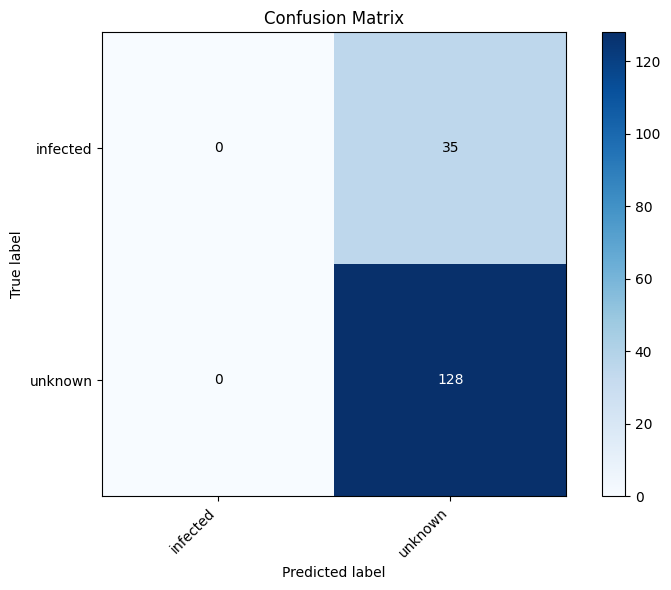

Saved confusion matrix to confusion_matrix.png


In [35]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)
ax.set(xticks=np.arange(len(class_names[:len(labels_for_sklearn)])),
       yticks=np.arange(len(class_names[:len(labels_for_sklearn)])),
       xticklabels=class_names[:len(labels_for_sklearn)],
       yticklabels=class_names[:len(labels_for_sklearn)],
       ylabel='True label', xlabel='Predicted label', title='Confusion Matrix')
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
thresh = cm.max() / 2. if cm.max() > 0 else 0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black")
plt.tight_layout()
plt.savefig(CONF_MATRIX_PNG, dpi=150)
plt.show()
print(f"Saved confusion matrix to {CONF_MATRIX_PNG}")


In [36]:
import pandas as pd
pred_prob = pred_logits.max(axis=1) if 'pred_logits' in globals() else np.max(pred_idxs, axis=1)
out_df = pd.DataFrame({
    "filepath": filepaths,
    "true_idx": y_true,
    "true_label": [class_names[i] for i in y_true],
    "pred_idx": pred_idxs,
    "pred_label": [class_names[i] for i in pred_idxs],
    "pred_prob": pred_prob
})
out_df.to_csv(OUT_CSV, index=False)
print(f"Saved predictions to {OUT_CSV}")


Saved predictions to test_predictions.csv
